In [1]:
%pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 94.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling 

In [1]:
import kagglehub

# Download latest version
caminho = kagglehub.dataset_download("phucthaiv02/butterfly-image-classification")

print("Local dos arquivos:b", caminho)

Local dos arquivos:b /kaggle/input/butterfly-image-classification


In [2]:
!rm -rf /content/butterfly

In [3]:
!mkdir /content/butterfly

In [4]:
import shutil

shutil.move(caminho, '/content/butterfly')

OSError: [Errno 30] Read-only file system: 'Training_set.csv'

In [5]:
caminho = '/content/butterfly/butterfly-image-classification'

In [6]:
import pandas as pd
from pathlib import Path

# Read the CSV files
train_df = pd.read_csv(Path(caminho) / 'Training_set.csv')
valid_df = pd.read_csv(Path(caminho) / 'Testing_set.csv')

In [7]:
# Separate train/validation dataframes stratified by label
train_df2 = train_df.groupby('label').sample(frac=0.7, random_state=42)
# Separate test
valid_df = train_df.drop(train_df2.index)
valid_df2 = valid_df.groupby('label').sample(frac=0.5, random_state=42)
test_df2 = valid_df.drop(valid_df2.index)

In [8]:
# Move train data
for index, row in train_df2.iterrows():
    filename = row['filename']
    label = row['label']
    source_path = Path(caminho) / 'train' / filename
    destination_path = Path(caminho) / 'train' / label
    destination_path.mkdir(parents=True, exist_ok=True)
    shutil.move(source_path, destination_path)

In [9]:
# Move validation data
for index, row in valid_df2.iterrows():
    filename = row['filename']
    label = row['label']
    source_path = Path(caminho) / 'train' / filename
    destination_path = Path(caminho) / 'val' / label
    destination_path.mkdir(parents=True, exist_ok=True)
    shutil.move(source_path, destination_path)

In [10]:
# Move test data away (don't have labels)
!mv {caminho}/test {caminho}/../test_bkp

In [11]:
# Move test data
for index, row in test_df2.iterrows():
    filename = row['filename']
    label = row['label']
    source_path = Path(caminho) / 'train' / filename
    destination_path = Path(caminho) / 'test' / label
    destination_path.mkdir(parents=True, exist_ok=True)
    shutil.move(source_path, destination_path)

In [12]:
from ultralytics import YOLO

# Load the YOLOv11 classification model (ImageNet)
model = YOLO('yolo11n-cls.pt')  # Use the nano model for quick training

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 5.52M/5.52M [00:00<00:00, 111MB/s]


In [13]:
print(model.model)

ClassificationModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C3k2(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
  

In [14]:
# Train the model
model.train(data=Path(caminho),
            epochs=10,
            batch=32,
            imgsz=224,
            freeze=9
            )  # Use your dataset

Ultralytics 8.3.141 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/butterfly/butterfly-image-classification, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=9, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True,

100%|██████████| 5.35M/5.35M [00:00<00:00, 95.8MB/s]


AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1093.4±418.2 MB/s, size: 28.1 KB)


train: Scanning /content/butterfly/butterfly-image-classification/train... 4544 images, 0 corrupt: 100%|██████████| 4544/4544 [00:00<00:00, 5826.97it/s]

train: New cache created: /content/butterfly/butterfly-image-classification/train.cache


...

                   all      0.892      0.977



10 epochs completed in 0.076 hours.
Optimizer stripped from runs/classify/train/weights/last.pt, 3.4MB
Optimizer stripped from runs/classify/train/weights/best.pt, 3.4MB

Validating runs/classify/train/weights/best.pt...
Ultralytics 8.3.141 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n-cls summary (fused): 47 layers, 1,622,099 parameters, 0 gradients, 3.2 GFLOPs
train: /content/butterfly/butterfly-image-classification/train... found 4544 images in 75 classes ✅ 
val: /content/butterfly/butterfly-image-classification/val... found 977 images in 75 classes ✅ 
test: /content/butterfly/butterfly-image-classification/test... found 978 images in 75 classes ✅ 


               classes   top1_acc   top5_acc: 100%|██████████| 16/16 [00:01<00:00,  9.05it/s]


                   all      0.892      0.977
Speed: 0.1ms preprocess, 0.5ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs/classify/train


ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79d2b7a033d0>
curves: []
curves_results: []
fitness: 0.9344933331012726
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.8915045857429504, 'metrics/accuracy_top5': 0.9774820804595947, 'fitness': 0.9344933331012726}
save_dir: PosixPath('runs/classify/train')
speed: {'preprocess': 0.11299341555767026, 'inference': 0.4638684442170648, 'loss': 0.00020674206763789826, 'postprocess': 0.0003548505628574702}
task: 'classify'
top1: 0.8915045857429504
top5: 0.9774820804595947

In [15]:
import os
from pathlib import Path

# Path to the test directory
test_dir = Path(caminho) / "test"

# Collect all test images with their class names
test_images = []
test_labels = []

for class_name in os.listdir(test_dir):
    class_path = Path(test_dir) / class_name
    if class_path.is_dir():
        for img_path in class_path.glob("*.jpg"):  # Adjust for your image format
            test_images.append(str(img_path))
            test_labels.append(class_name)

# Check the number of images collected
print(f"Found {len(test_images)} test images across {len(set(test_labels))} classes.")

Found 978 test images across 75 classes.


In [16]:
results = model.predict(source=test_images, save=False)


0: 224x224 MANGROVE SKIPPER 0.31, MOURNING CLOAK 0.15, ULYSES 0.06, GREEN CELLED CATTLEHEART 0.05, RED POSTMAN 0.05, 0.3ms
1: 224x224 MANGROVE SKIPPER 0.51, METALMARK 0.08, TWO BARRED FLASHER 0.06, ATALA 0.05, MOURNING CLOAK 0.04, 0.3ms
2: 224x224 MANGROVE SKIPPER 0.97, PIPEVINE SWALLOW 0.02, SOOTYWING 0.00, RED POSTMAN 0.00, CHESTNUT 0.00, 0.3ms
3: 224x224 MANGROVE SKIPPER 0.95, PIPEVINE SWALLOW 0.01, COMMON BANDED AWL 0.01, PURPLE HAIRSTREAK 0.01, ADONIS 0.01, 0.3ms
4: 224x224 MANGROVE SKIPPER 0.89, PURPLE HAIRSTREAK 0.05, PIPEVINE SWALLOW 0.03, GREY HAIRSTREAK 0.01, SOOTYWING 0.00, 0.3ms
5: 224x224 MANGROVE SKIPPER 0.87, PURPLE HAIRSTREAK 0.06, SOOTYWING 0.02, PIPEVINE SWALLOW 0.02, COMMON BANDED AWL 0.01, 0.3ms
6: 224x224 MANGROVE SKIPPER 0.96, TWO BARRED FLASHER 0.01, SOOTYWING 0.00, PIPEVINE SWALLOW 0.00, BLUE SPOTTED CROW 0.00, 0.3ms
7: 224x224 MANGROVE SKIPPER 0.97, PIPEVINE SWALLOW 0.01, SOOTYWING 0.00, PURPLE HAIRSTREAK 0.00, COMMON BANDED AWL 0.00, 0.3ms
8: 224x224 MANGROVE

In [17]:
import torch

# Extract predictions for each image
predicted_classes = []
predicted_confidences = []

for result in results:
    if result.probs:
        # Get the class IDs and confidence scores of the predictions
        max_index = torch.argmax(result.probs.data).tolist()
        predicted_classes.append(max_index)
        predicted_confidences.append(result.probs.data[max_index].tolist())
    else:
        # No predictions for this image
        predicted_classes.append([])
        predicted_confidences.append([])

# Map predicted class IDs to class names (if needed)
class_mapping = {i: class_name for i, class_name in enumerate(sorted(os.listdir(test_dir)))}
mapped_classes = [class_mapping[preds] for preds in predicted_classes]

In [18]:
# Error matrix

from sklearn.metrics import confusion_matrix
import numpy as np

true = test_labels
pred = mapped_classes

mat = confusion_matrix(true, pred)
#
mat

array([[11,  0,  0, ...,  0,  0,  0],
       [ 0, 11,  0, ...,  0,  0,  0],
       [ 0,  0,  9, ...,  0,  0,  0],
       ...,
       [ 0,  0,  0, ..., 11,  0,  0],
       [ 0,  0,  0, ...,  0, 10,  0],
       [ 0,  0,  0, ...,  0,  0, 11]])

MOURNING CLOAK
SOOTYWING


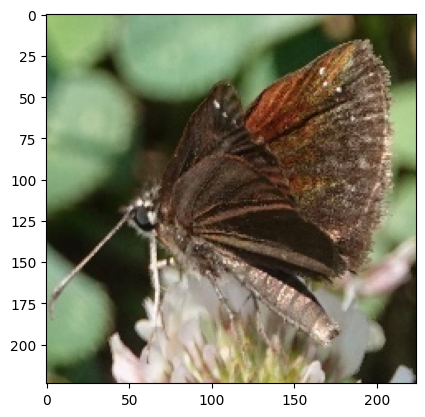

In [35]:
import numpy as np
from PIL import Image
from matplotlib import pyplot as plt

acertou = np.array(pred) == np.array(true)
acertou[90:100]
img = Image.open(test_images[90])
plt.imshow(img)
print(pred[90])
print(true[90])


SOOTYWING
SOOTYWING


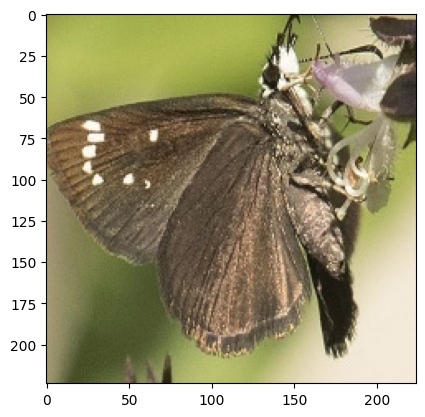

In [37]:
img = Image.open(test_images[91])
plt.imshow(img)
print(pred[91])
print(true[91])

In [19]:
metrics = {}

i = 0
for cls in np.unique(true):
    tp = mat[i, i]
    fp = np.sum(mat[:, i]) - tp
    fn = np.sum(mat[i, :]) - tp
    tn = np.sum(mat) - tp - fp - fn
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    metrics[cls] = {"Precision": precision, "Recall": recall}
    i += 1


In [20]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Convert metrics to DataFrame
data = pd.DataFrame([
    {"Class": cls, "Precision": m["Precision"], "Recall": m["Recall"]}
    for cls, m in metrics.items()
])

# Create scatter plot
fig = px.scatter(
    data,
    x="Precision",
    y="Recall",
    title="Interactive Scatter Plot: Precision vs Recall",
    labels={"x": "Precision", "y": "Recall"},
    color="Class",
    color_discrete_sequence=px.colors.qualitative.Set2
)

# Add horizontal and vertical lines at 0.5
fig.add_shape(
    type="line",
    x0=0.5, y0=0, x1=0.5, y1=2,  # Vertical line at x=0.5
    line=dict(color="gray", width=2, dash="dash")
)
fig.add_shape(
    type="line",
    x0=0, y0=0.5, x1=2, y1=0.5,  # Horizontal line at y=0.5
    line=dict(color="gray", width=2, dash="dash")
)

# Set axis ranges to 0–1
fig.update_layout(
    xaxis=dict(range=[-0.1, 1.1]),
    yaxis=dict(range=[-0.1, 1.1]),
    hovermode="closest"
)

# Show the plot
fig.show()

In [21]:
overall_accuracy = np.trace(mat) / np.sum(mat)
print(f"Overall Accuracy: {overall_accuracy}")

Overall Accuracy: 0.8997955010224948


In [22]:
type(model.model)

ultralytics.nn.tasks.ClassificationModel

In [ ]:
from google.colab import runtime
runtime.unassign()